<a href="https://colab.research.google.com/github/dewangsatyam/langchain_academy/blob/main/trim_filter_messages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture --no-stderr
%pip install --q -U langchain_core langgraph langchain-google-genai

In [ ]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
    temperature=0.7,
    google_api_key=GEMINI_API_KEY
)

# Reducer

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage
from IPython.display import display, Image
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import RemoveMessage

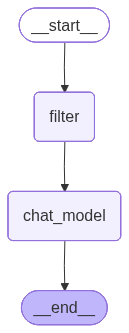

In [ ]:
def filter_messages(state: MessagesState):
  delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
  return {'messages': delete_messages}

def chat_model_node(state: MessagesState):
  return {'messages': [llm.invoke(state['messages'])]}

builder = StateGraph(MessagesState)
builder.add_node('filter', filter_messages)
builder.add_node('chat_model', chat_model_node)
builder.add_edge(START, 'filter')
builder.add_edge('filter', 'chat_model')
builder.add_edge('chat_model', END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
messages = [AIMessage('Hi.', name='Bot',id='1')]
messages.append(HumanMessage('Hi', name = 'Dev', id = '2'))
messages.append(AIMessage('So you really do not know anything about llm observability even though you are an aspiring AI Engineer', name='Bot', id = '3'))
messages.append(HumanMessage('Yes, Kindly tell me about Langfuse and teach me the basics.', name = 'Dev', id = '4'))

In [ ]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
  m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you really do not know anything about llm observability even though you are an aspiring AI Engineer
================================ Human Message =================================
Name: Dev

Yes, Kindly tell me about Langfuse and teach me the basics.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'First off, **don’t sweat it!** LLM Observability is a very new field (barely two years old). As an aspiring AI Engineer, learning this *now* actually puts you ahead of 90% of traditional software engineers moving into AI.\n\nThink of **LLM Observability** as the "X-ray machine" for your AI applications. \n\nWhen you build a normal app, debugging is easy: input goes in, code runs, output comes out. But with LLMs, the outputs are unpredictable, API calls are expensive, and latency (speed) is a massive issue. You cannot build a production-gr

# Trim Messages

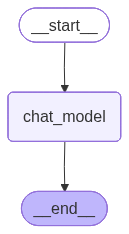

In [ ]:
from langchain_core.messages import trim_messages

def chat_model_node(state: MessagesState):
  messages = trim_messages(
      state['messages'],
      max_tokens=100,
      strategy='last',
      token_counter=llm
  )
  return {'messages': [llm.invoke(messages)]}

builder = StateGraph(MessagesState)
builder.add_node('chat_model', chat_model_node)
builder.add_edge(START, 'chat_model')
builder.add_edge('chat_model', END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
messages.append(output['messages'][-1])
messages.append(HumanMessage('But I have a custom class defined for calling my openAI model since it is a custom url', name = 'Dev'))

In [ ]:
trim_messages(messages,
              max_tokens=500,
              strategy='last',
              token_counter= llm,
              allow_partial = True)

[AIMessage(content='If you build a complex RAG (Retrieval-Augmented Generation) system or an AI Agent, a single user prompt might trigger 5 database searches and 3 different LLM calls. \nIn the Langfuse UI, you get a beautiful visual tree showing exactly what happened, in what order, and where it failed or got slow.\n\n#### B. Prompt Management\nInstead of hardcoding your prompts in Python (e.g., `prompt = "You are a helpful assistant..."`), you can host your prompts on Langfuse. \n* You can edit prompts in the Langfuse UI without redeploying your code.\n* It supports **version control** for prompts (e.g., Prompt v1 vs Prompt v2).\n\n#### C. Evaluations (Feedback Loops)\nHow do you know if your AI is actually doing a good job? \n* **User Feedback:** You can easily send "thumbs up/down" clicks from your frontend to Langfuse and attach them to the specific Trace.\n* **LLM-as-a-Judge:** You can set up Langfuse to automatically use a cheaper LLM (like GPT-3.5) to grade your main LLM\'s out

In [ ]:
messages_out_trim = graph.invoke({'messages': messages})
for m in messages_out_trim['messages']:
  m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Dev

Hi
================================== Ai Message ==================================
Name: Bot

So you really do not know anything about llm observability even though you are an aspiring AI Engineer
================================ Human Message =================================
Name: Dev

Yes, Kindly tell me about Langfuse and teach me the basics.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'First off, **don’t sweat it!** LLM Observability is a very new field (barely two years old). As an aspiring AI Engineer, learning this *now* actually puts you ahead of 90% of traditional software engineers moving into AI.\n\nThink of **LLM Observability** as the "X-ray machine" for your AI applications. \n\nWhen you build a normal app, debugging is ea